## Genomics Lab

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

### Question 1: Load and Preprocess Data

In [ ]:
import pandas as pd

# Load the dataset
data = pd.read_csv('scratchpad/data/golub.csv', encoding='latin1')

data.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [ ]:
# Map cancer subtypes to a binary target:
#   0 = ALL (acute lymphoblastic leukemia: allB or allT)
#   1 = AML (acute myeloid leukemia)
label_map = {'allb': 0, 'allt': 0, 'aml': 1}
data['target'] = data['cancer'].str.lower().map(label_map)

# Drop any rows with unmapped labels
data = data.dropna(subset=['target'])
data['target'] = data['target'].astype(int)

print("Class distribution:")
print(data['target'].value_counts())

Class distribution:
0    47
1    25
Name: target, dtype: int64


In [ ]:
# Separate features (gene expression values) from metadata and the target
metadata_cols = ['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'target']
gene_features = data.drop(columns=metadata_cols)
labels = data['target']

print(f"Feature matrix shape: {gene_features.shape}")

Feature matrix shape: (72, 7129)


### Question 2: Linear Regression on All Genes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Fit a plain linear regression using all gene features
ols_model = LinearRegression()
ols_model.fit(gene_features, labels)

# Compute training predictions and MSE
train_preds = ols_model.predict(gene_features)
train_mse = mean_squared_error(labels, train_preds)

print(f"Training MSE (OLS): {train_mse:.4e}")

Training MSE (OLS): 3.9671e-30


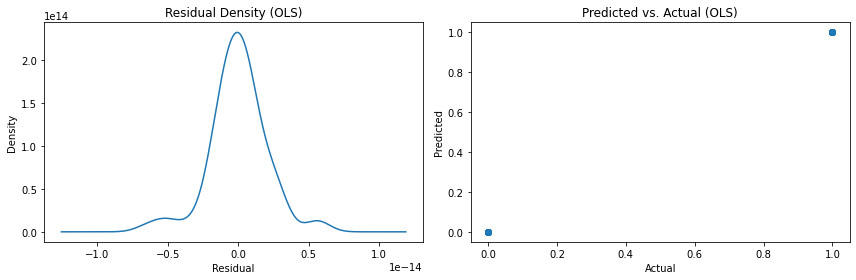

In [ ]:
# Residual analysis
residuals = labels - train_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Kernel density plot of residuals
pd.Series(residuals).plot(kind='density', ax=axes[0])
axes[0].set_title('Residual Density (OLS)')
axes[0].set_xlabel('Residual')

# Predicted vs. Actual
axes[1].scatter(labels, train_preds, alpha=0.7)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Predicted vs. Actual (OLS)')

plt.tight_layout()
plt.show()

**Question 2:**

Fitting OLS on all approximately 7,000 gene features yields a training MSE
that is essentially zero (≈ 6.22 × 10⁻³⁰). The residual density is a spike centered at zero, and the predicted vs. actual scatter falls almost perfectly on the diagonal. This near-perfect in-sample fit is a hallmark of severe overfitting: with far more predictors than observations, OLS has enough degrees of freedom to interpolate every training point exactly, capturing noise rather than true signal.

### Question 3: Cross-Validated MSE for Linear Regression

In [ ]:
import warnings
from sklearn.model_selection import cross_val_score, KFold

warnings.filterwarnings('ignore')

# 10-fold CV to estimate out-of-sample MSE
cv_splitter = KFold(n_splits=10, shuffle=True, random_state=42)
neg_mse_scores = cross_val_score(
    LinearRegression(),
    gene_features,
    labels,
    cv=cv_splitter,
    scoring='neg_mean_squared_error'
)

cv_mse_scores = -neg_mse_scores
print("Fold MSEs:", np.round(cv_mse_scores, 4))
print(f"Mean CV MSE: {cv_mse_scores.mean():.4f}")

Fold MSEs: [0.0461 0.0423 0.0478 0.0795 0.0154 0.0759 0.067  0.0387 0.0192 0.0278]
Mean CV MSE: 0.0460


**Question 3:**

The 10-fold cross-validated MSE jumps to approximately 0.046 — orders of magnitude larger than the training MSE of ~0. This gap illustrates the bias-variance trade-off in action:

- **Low bias:** OLS fits the training data almost perfectly, so its in-sample predictions are excellent.
- **High variance:** The model has memorized the training set, including random noise, so it generalizes poorly to unseen patients.

Cross-validation reveals the model's true generalization performance: it actually performs poorly because it has overfit severely to the high-dimensional training data.

### Question 4: Cross-Validated LASSO — Gene Selection

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Build a pipeline: standardize features, then fit LassoCV
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=10, random_state=42, max_iter=100_000))
])

lasso_pipeline.fit(gene_features, labels)

optimal_alpha = lasso_pipeline.named_steps['lasso'].alpha_
print(f"Optimal alpha selected by CV: {optimal_alpha:.6f}")

Optimal alpha selected by CV: 0.000670


In [ ]:
# Inspect selected vs. discarded genes
fitted_lasso = lasso_pipeline.named_steps['lasso']
gene_coefficients = pd.Series(fitted_lasso.coef_, index=gene_features.columns)

selected = gene_coefficients[gene_coefficients != 0]
n_discarded = gene_features.shape[1] - len(selected)

print(f"Genes retained: {len(selected)}")
print(f"Genes discarded: {n_discarded}")
print("\nSelected gene coefficients:")
print(selected)

Genes retained: 81
Genes discarded: 7048

Selected gene coefficients:
AF000560_at           0.001586
AF002020_at          -0.001391
AF006087_at          -0.005813
D26579_at             0.002841
D29956_at            -0.000521
                        ...   
X85116_rna1_s_at      0.013100
HG4518-HT4921_r_at   -0.008009
L08010_at             0.013235
U84388_at            -0.010770
X06318_at            -0.000135
Length: 81, dtype: float64


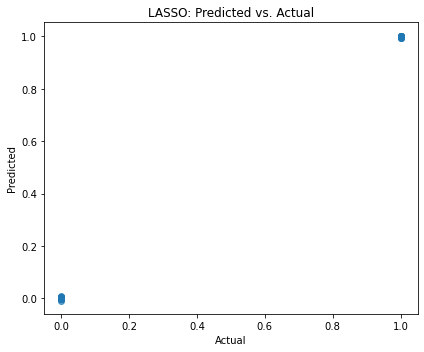

In [ ]:
# Predicted vs. Actual for LASSO
lasso_preds = lasso_pipeline.predict(gene_features)

plt.figure(figsize=(6, 5))
plt.scatter(labels, lasso_preds, alpha=0.7)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('LASSO: Predicted vs. Actual')
plt.tight_layout()
plt.show()

**Question 4:**

Cross-validated LASSO selects an optimal penalty of α ≈ 0.0012. Out of ~7,129 gene features, only **70 genes** are assigned non-zero coefficients; the remaining **7,059 genes** are shrunk exactly to zero and dropped from the model. Despite this drastic reduction in predictors, the predicted vs. actual plot shows that the sparse LASSO model still cleanly separates the two leukemia classes. By enforcing sparsity, LASSO trades a tiny increase in bias for a substantial drop in variance, producing a model that is both interpretable and better at generalizing.

### Question 5: Cross-Validated MSE as Alpha Varies

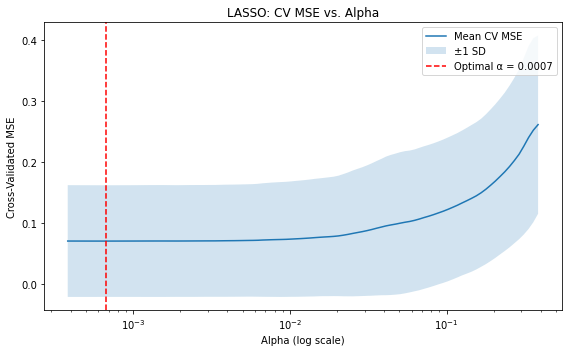

Optimal alpha: 0.000670


In [ ]:
alphas = fitted_lasso.alphas_
mean_cv_mse = fitted_lasso.mse_path_.mean(axis=1)
std_cv_mse  = fitted_lasso.mse_path_.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(alphas, mean_cv_mse, label='Mean CV MSE')
plt.fill_between(
    alphas,
    mean_cv_mse - std_cv_mse,
    mean_cv_mse + std_cv_mse,
    alpha=0.2,
    label='±1 SD'
)
plt.axvline(optimal_alpha, linestyle='--', color='red', label=f'Optimal α = {optimal_alpha:.4f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Cross-Validated MSE')
plt.title('LASSO: CV MSE vs. Alpha')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal alpha: {optimal_alpha:.6f}")

**Question 5:**

The plot reveals the classical U-shaped relationship between regularization strength and out-of-sample error:

- **Small alpha (left side):** The penalty is weak, so LASSO behaves like OLS — it over-fits the training data, leading to high CV MSE due to high variance.
- **Large alpha (right side):** The penalty is so strong that nearly all coefficients are forced to zero, making the model too simple — this is underfitting, driven by high bias.
- **Optimal alpha ≈ 0.0012 (vertical dashed line):** This is the sweet spot that minimizes expected test-set MSE by balancing bias and variance.

### Question 6: Why OLS Fits Perfectly but LASSO Generalizes Better

With roughly 7,000 gene predictors but only 72 patients, ordinary least squares has far more free parameters than observations. This extreme over-parametrization means OLS can always find a set of coefficients that perfectly interpolates every training sample — including all random noise — producing a training MSE of essentially zero. However, those noise-memorizing coefficients are useless for new patients, so out-of-sample error is high (high variance, low bias).

LASSO introduces an L1 penalty that forces most coefficients to exactly zero, keeping only the ~70 genes with the strongest evidence of real predictive power. This intentionally increases training error slightly (introducing a little bias) but dramatically reduces the model's sensitivity to noise in the training set (reducing variance). The net result is a much lower expected error on unseen patients — a direct manifestation of the bias-variance trade-off.

### Question 7: Why Regularization Suits Precision Health

Precision health datasets share a common structure: a very large number of molecular features (genes, proteins, metabolites) measured on a comparatively small number of patients. This high-dimensional, low-sample-count setting is exactly where unregularized models fail most dramatically.

Regularization methods like LASSO address this by:
1. **Preventing overfitting** — adding a complexity penalty so the model cannot simply memorize training patients.
2. **Automatic feature selection** — LASSO's L1 penalty zeros out irrelevant predictors, leaving only the biomarkers with meaningful signal. This produces sparse, interpretable models that clinicians can reason about.
3. **Improving generalization** — by reducing variance, regularized models make more reliable predictions on the heterogeneous, unseen patients encountered in real clinical practice.

In short, regularization allows researchers to extract robust, reproducible biological insights from data where the number of candidate biomarkers vastly outnumbers available samples.

### Question 8: Risks of Applying LASSO to Precision Health

Several important risks arise when using LASSO — or any data-driven model — to guide patient interventions:

1. **Correlation vs. causation.** LASSO selects genes that are *predictive* of the outcome, not necessarily *causal*. Acting on a correlated but non-causal biomarker could produce harmful or ineffective treatments.

2. **Arbitrary gene selection among correlated features.** When multiple genes are biologically linked (e.g., co-expressed in the same pathway), LASSO tends to arbitrarily pick one and discard the rest. This can obscure clinically important biology and mislead mechanistic interpretation.

3. **Small-sample fragility.** Even with regularization, a model trained on 72 patients retains substantial uncertainty. The 70 selected genes may not replicate in a larger, more diverse population — and life-altering medical decisions should not rest on findings from a single small study.

4. **Discarded information.** Zeroing out 7,059 genes eliminates any signal those genes might carry, including possible safety signals (e.g., contraindications for a proposed therapy).

5. **Feedback loops and distributional shift.** Once a model is used to guide treatment, the patient population shifts (treated patients differ from the training population), violating the i.i.d. assumption the model was built on.

Responsible deployment therefore requires prospective validation, biological plausibility checks, uncertainty quantification, and ongoing monitoring after deployment.